# 3η Εργασία

Μπαρμπαγιάννος Βασίλειος

ΑΕΜ: 10685

Τμήμα Ηλεκτρολόγων Μηχανικών και Μηχανικών Υπολογιστών


# Εκφώνηση

Να γραφεί πρόγραμμα σε οποιαδήποτε γλώσσα προγραμματισμού το οποίο να υλοποιεί ένα
Radial Basis Function Neural Network ή ένα δίκτυο που εκπαιδεύεται με Hebbian Learning ή
ένα δίκτυο αυτοκωδικοποίησης (autoencoder ή transformer) που θα εκπαιδευτεί για να επιλύει
ένα από τα προβλήματα που επιλύσατε στις προηγούμενες εργασίες σας ή αντίστοιχο πρόβλημα
προσέγγισης συνάρτησης ή δημιουργίας δεδομένων.

Ενδεικτικά:

1. Ανακατασκευή ψηφίων ή αθροιστής στα δεκαδικά ψηφία (0,1,...,9) της MNIST:

http://www.cs.toronto.edu/~roweis/data.html

2. Διαχωρισμό 2 ή όλων των κλάσεων ή ανακατασκευή δειγμάτων που υπάρχουν στις Cifar
10 ή SVHN και βρίσκονται στις παρακάτω διευθύνσεις:

https://www.cs.toronto.edu/~kriz/cifar.html

http://ufldl.stanford.edu/housenumbers/

3. ή να επιλύει οποιοδήποτε πρόβλημα κατηγοριοποίησης πολλών κλάσεων ή προσέγγισης
συνάρτησης ή ανακατασκευής δεδομένων από τις βάσεις που βρίσκονται στις παρακάτω
σελίδες:

http://archive.ics.uci.edu/ml/

http://www.cs.toronto.edu/~roweis/data.html

http://www.cs.cmu.edu/~cil/v-images.html

https://www.kaggle.com/datasets

Όπου δεν υπάρχει σύνολο ελέγχου χωρίζεται η βάση τυχαία σε σύνολο εκπαίδευσης (60%) και
ελέγχου (40%) ή ακολουθείται τεχνική cross-validation.

**Εξαγωγή Χαρακτηριστικών**

Για το διαχωρισμό των δειγμάτων μπορεί να μειώνεται πρώτα η διάσταση των δεδομένων
χρησιμοποιώντας PCA ώστε να κρατήσετε περισσότερο από 90% της πληροφορίας.

**Έκθεση Αποτελεσμάτων**

Θα πρέπει να γραφεί έκθεση στην οποία να περιγράφονται: ο αλγόριθμος, να δίνονται
χαρακτηριστικά παραδείγματα ορθής και εσφαλμένης κατηγοριοποίησης ή ανακατασκευής καθώς και
ποσοστά επιτυχίας στα στάδια της εκπαίδευσης (training) και του ελέγχου (testing), χρόνος
εκπαίδευσης και ποσοστά επιτυχίας για διαφορετικούς αριθμούς κρυφών νευρώνων, τρόπο
εκπαίδευσης (Κ-μέσους, τυχαία επιλογή κέντρων, κτλ) καθώς και διαφορετικές τιμές των παραμέτρων
εκπαίδευσης. Να συγκριθεί η απόδοση του RBF σε σχέση με την κατηγοριοποίηση πλησιέστερου
γείτονα (Nearest Neighbor) και πλησιέστερου κέντρου κλάσης (Nearest Class Centroid) ενώ αν
επιλεγεί Hebbian Learning ή autoencoder να συγκριθεί με ανακατασκευή μέσω PCA. Στην περίπτωση
της MNIST θα μπορούσατε να ελέγξετε κατά πόσο το ανακατασκευασμένο ψηφίο μπορεί να
αναγνωριστεί από ένα νευρωνικό αναγνώρισης ψηφίων. Άλλο πιθανό project ανακατασκευής θα ήταν
να φτιάξετε έναν αθροιστή που να παίρνει στην είσοδο 2 ψηφία της MNIST και να βγάζει στην έξοδο
2 ψηφία που θα είναι το άθροισμα τους. Για παράδειγμα 9, 7 θα παράξουν 1, 6. Να σχολιασθούν τα
αποτελέσματα και ο κώδικας.


# 1 Λήψη δεδομένων και εισαγωγή απαραίτητων βιβλιοθηκών


In [ ]:
# Κατεβάζουμε το dataset (αν δεν υπάρχει ήδη).
!wget -N https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz

# Αποσυμπιέζουμε το αρχείο.
!tar -xzf cifar-100-python.tar.gz

# Εισάγουμε τις βιβλιοθήκες που θα χρειαστούμε.
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import pickle

from sklearn.cluster import MiniBatchKMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

import torch

# Ελέγχουμε αν υπάρχει GPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

--2026-01-04 09:34:48--  https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 169001437 (161M) [application/x-gzip]
Saving to: ‘cifar-100-python.tar.gz’

cifar-100-python.ta 100%[===================>] 161.17M  46.2MB/s    in 3.9s    

2026-01-04 09:34:52 (41.3 MB/s) - ‘cifar-100-python.tar.gz’ saved [169001437/169001437]

Using device: cpu


# 2 Εξαγωγή των δεδομένων


Loaded CIFAR-100: x_train (50000, 3072) x_test (10000, 3072) classes 100


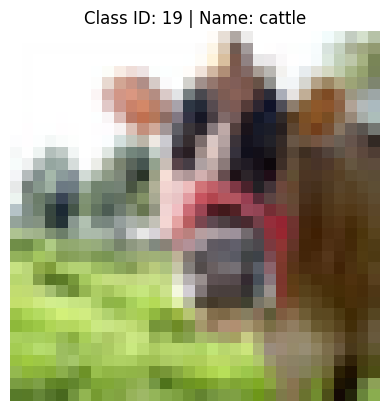

In [ ]:
# Φάκελος στον οποίο βρίσκεται το CIFAR-100 dataset.
DATA_DIR = "cifar-100-python"

# Unpickle των δεδομένων.
def unpickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='bytes')

# Φορτώνω τα train και test datasets.
train_dict = unpickle(os.path.join(DATA_DIR, "train"))
test_dict = unpickle(os.path.join(DATA_DIR, "test"))
meta_dict = unpickle(os.path.join(DATA_DIR, "meta"))

# Αποθήκευση των εικόνων και των ετικετών σε numpy arrays (για ταχύτητα).
x_train = train_dict[b'data'] # διάνυσμα 50.000x3072.
y_train = np.array(train_dict[b'fine_labels'], dtype=np.int64) # ετικέτες από 0 έως 99 (100 κλάσεις).
x_test = test_dict[b'data'] # διάνυσμα 10.000x3072.
y_test = np.array(test_dict[b'fine_labels'], dtype=np.int64)

# Λίστα με τα ονόματα των κλάσεων.
label_names = [n.decode('utf-8') for n in meta_dict[b'fine_label_names']]

print("Loaded CIFAR-100: x_train", x_train.shape, "x_test", x_test.shape, "classes", len(label_names))

# Συνάρτηση που μετατρέπει τις εικόνες από flat διανύσματα 1x3072 σε εικόνα Height, Width, Channel (32x32x3).
def flat_to_img_uint8(row):
    r = row[0:1024].reshape(32,32) # red.
    g = row[1024:2048].reshape(32,32) # green.
    b = row[2048:3072].reshape(32,32) # blue.
    img = np.dstack([r,g,b]).astype(np.uint8)
    return img

# Οπτικός έλεγχος μιας τυχαίας εικόνας για επιβεβαίωση
def plot_image(x_vector, y_label, class_names):
    # Μετατροπή από flat (3072) σε εικόνα (32, 32, 3)
    # Τα πρώτα 1024 είναι Red, τα επόμενα Green, τα τελευταία Blue
    r = x_vector[0:1024].reshape(32, 32)
    g = x_vector[1024:2048].reshape(32, 32)
    b = x_vector[2048:3072].reshape(32, 32)
    img = np.dstack([r, g, b]).astype(np.uint8)

    plt.imshow(img)
    plt.title(f"Class ID: {y_label} | Name: {class_names[y_label]}")
    plt.axis('off')
    plt.show()

# Δείξε την 1η εικόνα του train set.
plot_image(x_train[0], y_train[0], label_names)

# 3 Ανάλυση Κύριων Συνιστωσών - PCA


In [ ]:
# Κρατάω όλες τις κλάσεις.
# x_train: (50000, 3072)
# y_train: (50000,) με τιμές 0-99
print(f"Αρχικές Διαστάσεις (Train): {x_train.shape}")

# Κανονικοποίηση των δεδομένων.
# Μετασχηματίζουμε τα δεδομένα ώστε να έχουν μέση τιμή 0 και τυπική απόκλιση 1.

scaler = StandardScaler()

# Υπολογίζουμε τη μετατροπή στο train set και την εφαρμόζουμε.
x_train_scaled = scaler.fit_transform(x_train.astype(float))
# Εφαρμόζουμε την ίδια μετατροπή στο test set.
x_test_scaled = scaler.transform(x_test.astype(float))

# Εφαρμογή PCA (διατήρηση του 95% της πληροφορίας).
pca = PCA(n_components=0.95) # n_components = 0.95 => ποσοστό διακύμανσης 95%.
# Δηλαδή κράτησε τόσες στήλες όσες χρειάζονται για την διατήρηση του 95% της πληροφορίας.

# Χρονομετρώ.
start_time = time.time()

# Το PCA μαθαίνει ποιες διαστάσεις είναι σημαντικές από το train set
# και αποφασίζει πόσες στήλες θα κρατήσει, αυτόματα, από μόνο του.
x_train_pca = pca.fit_transform(x_train_scaled)
# Και προσαρμόζει το test set σε αυτές τις νέες διαστάσεις.
x_test_pca = pca.transform(x_test_scaled)

pca_time = time.time() - start_time # Μέτρηση διάρκειας εφαρμογής PCA (για στατιστικούς λόγους).
print(f"\nΤο PCA ολοκληρώθηκε σε {(pca_time/60):.2f} λεπτά.")

print(f"\nΔιαστάσεις πριν το PCA: {x_train.shape}")
print(f"Διαστάσεις μετά το PCA: {x_train_pca.shape}")
print(f"\nΑριθμός συνιστωσών (νέες στήλες) που διατηρήθηκαν: {pca.n_components_}")
print(f"Συνολική διακύμανση (πληροφορία) που κρατήσαμε (για επαλήθευση): {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

# Φτιάχνουμε τις μεταβλητές που θα μπουν στα μοντέλα.
X_train_final = x_train_pca
y_train_final = y_train

X_test_final = x_test_pca
y_test_final = y_test

Αρχικές Διαστάσεις (Train): (50000, 3072)

Το PCA ολοκληρώθηκε σε 2.58 λεπτά.

Διαστάσεις πριν το PCA: (50000, 3072)
Διαστάσεις μετά το PCA: (50000, 207)

Αριθμός συνιστωσών (νέες στήλες) που διατηρήθηκαν: 207
Συνολική διακύμανση (πληροφορία) που κρατήσαμε (για επαλήθευση): 95.02%


# 4 RBF Neural Network


In [ ]:
class RBFNetwork:
    def __init__(self, n_centers=100, method='kmeans', gamma=0.1, random_state=42):
        self.n_centers = n_centers
        self.method = method
        self.gamma = gamma
        self.random_state = random_state
        self.centers = None
        self.clf = LogisticRegression(solver='lbfgs', max_iter=1000, n_jobs=-1)

    def _calculate_activations(self, X):
        # Υπολογισμός αποστάσεων κάθε δείγματος από κάθε κέντρο.
        distances = euclidean_distances(X, self.centers, squared=True)
        # Εφαρμογή Gaussian συνάρτησης.
        return np.exp(-self.gamma * distances)

    def fit(self, X, y):
        # Εύρεση Κέντρων.
        if self.method == 'kmeans':
            kmeans = MiniBatchKMeans(n_clusters=self.n_centers, random_state=self.random_state, batch_size=256, n_init='auto')
            kmeans.fit(X)
            self.centers = kmeans.cluster_centers_
        else: # method == 'random'
            rng = np.random.RandomState(self.random_state)
            indices = rng.permutation(X.shape[0])[:self.n_centers]
            self.centers = X[indices]

        # Υπολογισμός RBF Activations και εκπαίδευση Linear Classifier.
        hidden_output = self._calculate_activations(X)
        self.clf.fit(hidden_output, y)

    def predict(self, X):
        hidden_output = self._calculate_activations(X)
        return self.clf.predict(hidden_output)

# --- ΠΡΟΕΤΟΙΜΑΣΙΑ ΔΕΔΟΜΕΝΩΝ ---
TRAIN_SAMPLES = 50000
X_train_rbf, y_train_rbf = shuffle(X_train_final, y_train_final, random_state=42, n_samples=TRAIN_SAMPLES)

print(f"Εκκίνηση Πειραμάτων RBF Neural Network σε {TRAIN_SAMPLES} δείγματα.\n")

results_rbf = []
gamma_val = 1.0 / X_train_rbf.shape[1]
# Για debugging.
print(X_train_rbf.shape)
print(gamma_val)

# Εκπαιδεύω μία φορά με kmeans και μία με random και κρατάω τον αλγόριθμο που δίνει καλύτερο accuracy.
methods = ['kmeans', 'random']
for m in methods:
    print(f"Running RBF: Method={m}, Neurons=200...")
    rbf = RBFNetwork(n_centers=200, method=m, gamma=gamma_val)

    # Χρονομέτρηση εκπαίδευσης (train).
    start_train = time.time()
    rbf.fit(X_train_rbf, y_train_rbf)
    train_time = time.time() - start_train

    # Χρονομέτρηση πρόβλεψης (test).
    start_test = time.time()
    y_pred_test = rbf.predict(X_test_final)
    test_time = time.time() - start_test

    test_acc = accuracy_score(y_test_final, y_pred_test)

    # train accuracy.
    train_acc = accuracy_score(y_train_rbf[:10000], rbf.predict(X_train_rbf[:10000]))

    results_rbf.append({
        'Neurons': 200,
        'Method': m,
        'Gamma': 'scale',
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Train Time (sec)': train_time,
        'Test Time (sec)': test_time
    })
    print(f"Done. Test Acc: {test_acc:.2%} | Train Time: {train_time:.2f}s | Test Time: {test_time:.2f}s")
print()
# Τώρα πειραματιζόμαστε με τον kmeans και διαφορετικό αριθμό νευρώνων.
neuron_counts = [100, 300, 500]
for n in neuron_counts:
    print(f"Running RBF: Method=kmeans, Neurons={n}...")
    rbf = RBFNetwork(n_centers=n, method='kmeans', gamma=gamma_val)

    # Χρονομέτρηση εκπαίδευσης.
    start_train = time.time()
    rbf.fit(X_train_rbf, y_train_rbf)
    train_time = time.time() - start_train

    # Χρονομέτρηση πρόβλεψης.
    start_test = time.time()
    y_pred_test = rbf.predict(X_test_final)
    test_time = time.time() - start_test

    test_acc = accuracy_score(y_test_final, y_pred_test)
    train_acc = accuracy_score(y_train_rbf[:10000], rbf.predict(X_train_rbf[:10000]))

    results_rbf.append({
        'Neurons': n,
        'Method': 'kmeans',
        'Gamma': 'scale',
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Train Time (sec)': train_time,
        'Test Time (sec)': test_time
    })
    print(f"Done. Test Acc: {test_acc:.2%}")

# Τώρα πειραματιζόμαστε με διαφορετικές τιμές gamma.
gammas = [0.001, 0.01, 0.1]
for g in gammas:
    print(f"Running RBF: Method=kmeans, Neurons=200, Gamma={g}...")
    rbf = RBFNetwork(n_centers=200, method='kmeans', gamma=g)

    # Χρονομέτρηση εκπαίδευσης.
    start_train = time.time()
    rbf.fit(X_train_rbf, y_train_rbf)
    train_time = time.time() - start_train

    # Χρονομέτρηση πρόβλεψης.
    start_test = time.time()
    y_pred_test = rbf.predict(X_test_final)
    test_time = time.time() - start_test

    test_acc = accuracy_score(y_test_final, y_pred_test)
    train_acc = accuracy_score(y_train_rbf[:10000], rbf.predict(X_train_rbf[:10000]))

    results_rbf.append({
        'Neurons': 200,
        'Method': 'kmeans',
        'Gamma': g,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Train Time (sec)': train_time,
        'Test Time (sec)': test_time
    })
    print(f"Done. Test Acc: {test_acc:.2%}")

# Συγκεντρωτικός πίνακας.
df_rbf = pd.DataFrame(results_rbf)
pd.options.display.float_format = '{:.4f}'.format
print("\n=== ΑΠΟΤΕΛΕΣΜΑΤΑ RBF NETWORK ===")
print(df_rbf)


Εκκίνηση Πειραμάτων RBF Neural Network σε 50000 δείγματα.

(50000, 207)
0.004830917874396135
Running RBF: Method=kmeans, Neurons=200...
Done. Test Acc: 4.71% | Train Time: 10.65s | Test Time: 0.14s
Running RBF: Method=random, Neurons=200...
Done. Test Acc: 4.27% | Train Time: 5.22s | Test Time: 0.15s

Running RBF: Method=kmeans, Neurons=100...
Done. Test Acc: 4.23%
Running RBF: Method=kmeans, Neurons=300...
Done. Test Acc: 5.07%
Running RBF: Method=kmeans, Neurons=500...
Done. Test Acc: 5.34%
Running RBF: Method=kmeans, Neurons=200, Gamma=0.001...
Done. Test Acc: 15.37%
Running RBF: Method=kmeans, Neurons=200, Gamma=0.01...
Done. Test Acc: 1.00%
Running RBF: Method=kmeans, Neurons=200, Gamma=0.1...
Done. Test Acc: 1.00%

=== ΑΠΟΤΕΛΕΣΜΑΤΑ RBF NETWORK ===
   Neurons  Method  Gamma  Train Acc  Test Acc  Train Time (sec)  \
0      200  kmeans  scale     0.0557    0.0471           10.6462   
1      200  random  scale     0.0456    0.0427            5.2218   
2      100  kmeans  scale     0.

Αφού το gamma = 0.001 δίνει το καλύτερο accuracy, τώρα θα δοκιμάσω να αυξήσω τους νευρώνες για να δω αν μπορώ να αυξήσω την ακρίβεια.


In [ ]:
# Βέλτιστο gamma = 0.001 με περισσότερους νευρώνες.

target_neurons = [300, 500, 750, 1000]
best_gamma = 0.001 # Το καλύτερο gamma.
method = 'kmeans'

print(f"Πειράματα για {target_neurons} νευρώνες με σταθερό gamma={best_gamma}...\n")

extra_results = []

for n in target_neurons:
    print(f"Running RBF: Method={method}, Neurons={n}, Gamma={best_gamma}...")

    # Δημιουργία του δικτύου.
    rbf = RBFNetwork(n_centers=n, method=method, gamma=best_gamma)

    # Χρονομέτρηση εκπαίδευσης.
    start_train = time.time()
    rbf.fit(X_train_rbf, y_train_rbf)
    train_time = time.time() - start_train

    # Χρονομέτρηση πρόβλεψης.
    start_test = time.time()
    y_pred_test = rbf.predict(X_test_final)
    test_time = time.time() - start_test

    # Υπολογισμός ακρίβειας. Το test accuracy μετριέται σε όλες τις 10.000 εικόνες του test dataset.
    test_acc = accuracy_score(y_test_final, y_pred_test)

    # train accuracy. Υπολογισμός του train accuracy στις 10.000 εικόνες.
    # Ασφαλώς το μοντέλο εκπαιδεύτηκε στις 50.000 εικόνες.
    train_acc = accuracy_score(y_train_rbf[:10000], rbf.predict(X_train_rbf[:10000]))

    # Αποθήκευση αποτελεσμάτων.
    extra_results.append({
        'Neurons': n,
        'Method': method,
        'Gamma': best_gamma,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Train Time (sec)': train_time,
        'Test Time (sec)': test_time
    })

    print(f"Done. Test Acc: {test_acc:.2%} | Train Time: {train_time:.2f}s")

df_extra = pd.DataFrame(extra_results)
pd.options.display.float_format = '{:.4f}'.format

print("\n=== ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(df_extra)

Πειράματα για [300, 500, 750, 1000, 10000] νευρώνες με σταθερό gamma=0.001...

Running RBF: Method=kmeans, Neurons=300, Gamma=0.001...
Done. Test Acc: 16.45% | Train Time: 44.35s
Running RBF: Method=kmeans, Neurons=500, Gamma=0.001...
Done. Test Acc: 17.73% | Train Time: 71.98s
Running RBF: Method=kmeans, Neurons=750, Gamma=0.001...
Done. Test Acc: 18.50% | Train Time: 137.68s
Running RBF: Method=kmeans, Neurons=1000, Gamma=0.001...
Done. Test Acc: 19.21% | Train Time: 168.22s
Running RBF: Method=kmeans, Neurons=10000, Gamma=0.001...


# 5 Παραδείγματα ορθής και εσφαλμένης ταξινόμησης


Εκπαίδευση του βέλτιστου RBF μοντέλου για οπτικοποίηση...


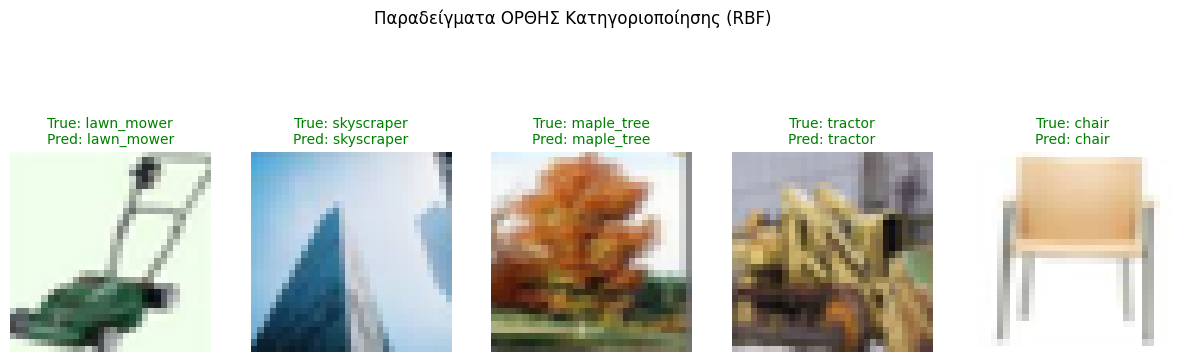

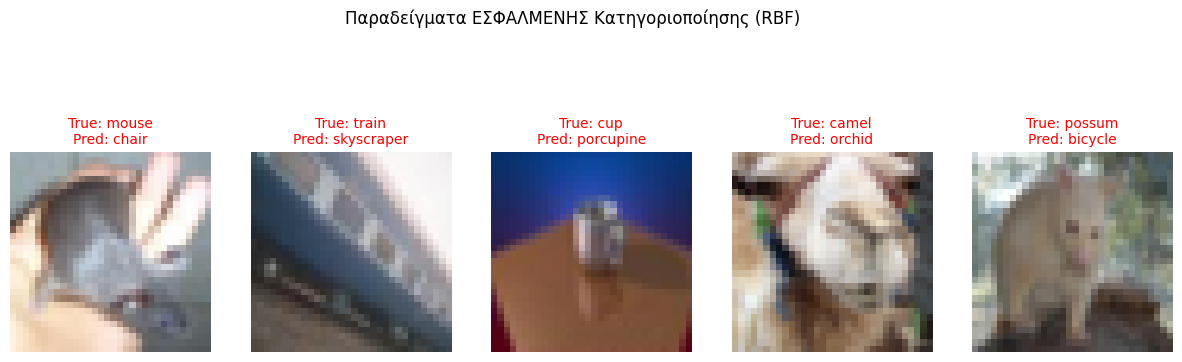

In [ ]:
print("Εκπαίδευση του βέλτιστου RBF μοντέλου για οπτικοποίηση...")


gamma_val = 1.0 / X_train_rbf.shape[1]

# Η πρόβλεψη θα γίνει με το καλύτερο RBF μοντέλο.
best_rbf = RBFNetwork(n_centers=500, method='kmeans', gamma=0.001)

# Εκπαίδευση.
best_rbf.fit(X_train_rbf, y_train_rbf)

# Προβλέψεις στο test set.
y_pred_vis = best_rbf.predict(X_test_final)

# Συνάρτηση για την οπτικοποίηση των δεδομένων.
def plot_classification_examples(x_raw, y_true, y_pred, label_names, correct=True, num_images=5):
    if correct:
        indices = np.where(y_true == y_pred)[0]
        title_text = "Παραδείγματα ΟΡΘΗΣ Κατηγοριοποίησης (RBF)"
    else:
        indices = np.where(y_true != y_pred)[0]
        title_text = "Παραδείγματα ΕΣΦΑΛΜΕΝΗΣ Κατηγοριοποίησης (RBF)"

    # Επιλογή τυχαίων εικόνων.
    if len(indices) > 0:
        # Αν βρήκαμε λιγότερες από 5, δείχνουμε όσες έχουμε.
        n_to_show = min(len(indices), num_images)
        selected_indices = np.random.choice(indices, n_to_show, replace=False)

        plt.figure(figsize=(15, 5))
        for i, idx in enumerate(selected_indices):
            plt.subplot(1, num_images, i + 1)

            img_flat = x_raw[idx]

            # Ανακατασκευή εικόνας.
            r = img_flat[0:1024].reshape(32, 32)
            g = img_flat[1024:2048].reshape(32, 32)
            b = img_flat[2048:3072].reshape(32, 32)
            img = np.dstack([r, g, b]).astype(np.uint8)

            plt.imshow(img)

            true_label = label_names[y_true[idx]]
            pred_label = label_names[y_pred[idx]]

            color = 'green' if correct else 'red'
            plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
            plt.axis('off')

        plt.suptitle(title_text)
        plt.show()
    else:
        print(f"Δεν βρέθηκαν δείγματα για την κατηγορία: {title_text}")

# 1. Εμφάνιση 5 σωστά ταξινομημένων.
plot_classification_examples(x_test, y_test_final, y_pred_vis, label_names, correct=True, num_images=5)

# 2. Εμφάνιση 5 λανθασμένα ταξινομημένων.
plot_classification_examples(x_test, y_test_final, y_pred_vis, label_names, correct=False, num_images=5)